## Configuración Inicial:


In [2]:
# 📥 Instalación de dependencias (ejecutar una vez)
!pip install librosa numpy matplotlib scipy ipywidgets
# 📚 Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy import signal
from IPython.display import Audio, display
import ipywidgets as widgets
from ipywidgets import interact
# ⚙️ Configuración de visualización
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Entorno listo. ¡Comencemos!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.4 MB/s eta 0:00:00
✅ Entorno listo. ¡Comencemos!


## Geración del Dataset Sintético:

In [3]:
def generar_dataset_sintetico (n_muestras=100, sr=22050, duracion=2.0):
  """Genera dataset sintético con 3 clases:
    -Calse 0 : Tono grave (200-400 Hz)
    -Calse 1 : Tono grave (600-1000 Hz)
    -Calse 2 : Tono grave (1500-2500 Hz)
    """
  dataset =[] # dentro de la función
  t= np.linspace(0, duracion, int(sr*duracion), endpoint=False) # Movido dentro de la función

  for i in range (n_muestras):
    for clase in range (3):
      #Frecuencias según clase
      if clase == 0: # Grave
          f1 = np.random.uniform(200, 300)
          f2 = np.random.uniform(400, 500)
      elif clase == 1 : # Medio
          f1 = np.random.uniform(600, 800)
          f2 = np.random.uniform(1000, 1200)
      else: # Agudo
          f1 = np.random.uniform (1500, 2000)
          f2 = np.random.uniform (2500, 3000)

      # Generar señal con 2 frecuecias + ruido
      señal = (0.6 * np.sin(2 * np.pi * f1 * t) + 0.3 * np.sin(2 * np.pi * f2 * t) + 0.05 * np.random.randn(len(t)))

      # Normalizar
      señal = señal / np.max(np.abs(señal)) * 0.9

      dataset.append ({
          'audio': señal,
          'sr': sr,
          'clase': clase,
          'etiqueta': ['Grave', 'Medio', 'Agudo'][clase],
          'f1_reales': f1,
          'f2_reales': f2
      })
  print (f" Dataset generado: {len (dataset)} muestras, 3 clases") # Movido fuera del bucle interno
  return dataset

dataset = generar_dataset_sintetico (n_muestras = 50)

 Dataset generado: 150 muestras, 3 clases


## Extracción Masiva de Features

In [4]:
from librosa.feature import mfcc
import pandas as pd # Importar pandas

def extraer_features_completas(audio,sr):

  features= {}

  features['rms'] = librosa.feature.rms (y=audio)[0].mean()
  features['zcr'] = librosa.feature.zero_crossing_rate (audio)[0].mean()

  features ['spectral centroid'] = librosa.feature.spectral_centroid (y=audio, sr=sr)[0].mean()
  features ['spectral bandwidth'] = librosa.feature.spectral_bandwidth (y=audio, sr=sr)[0].mean()
  features ['spectral rolloff'] = librosa.feature.spectral_rolloff (y=audio, sr=sr)[0].mean()
  features ['spectral flatness'] = librosa.feature.spectral_flatness (y=audio)[0].mean() # 'sr=sr' eliminado

  mfcc_features = librosa.feature.mfcc (y=audio, sr=sr, n_mfcc=5)
  for i in range (5):
      features [f'mfcc_{i}'] = mfcc_features[i].mean()

  features ['duracion'] = len (audio)/ sr
  return features

print ( "Extrayendo features...") # Movido fuera de la función
features_df = [] # Inicializado correctamente

for i, muestra in enumerate (dataset): # 'enamorate' corregido a 'enumerate'
  feats = extraer_features_completas (muestra ['audio'], muestra ['sr'])
  feats ['clase'] = muestra ['clase']
  feats ['etiqueta'] = muestra ['etiqueta']
  feats ['id'] = i
  features_df.append (feats)

  if (i+1) % 50 == 0:
    print(f"Progreso: {i+1}/{len(dataset)}") # f-string corregido
df = pd.DataFrame (features_df)
print (f"✅ Features extraidos: {df.shape[0]} muestras x {df.shape[1]} columnas") # f-string corregido

print("Primeras muestras:") # Corregido typo y mensaje
print(df.head())

Extrayendo features...
Progreso: 50/150
Progreso: 100/150
Progreso: 150/150
✅ Features extraidos: 150 muestras x 15 columnas
Primeras muestras:
        rms       zcr  spectral centroid  spectral bandwidth  \
0  0.398509  0.039242        3260.636376         3513.331693   
1  0.399389  0.065194        3492.012729         3341.568095   
2  0.403193  0.142724        3998.539461         2991.918973   
3  0.414448  0.039343        3246.637734         3515.863998   
4  0.405123  0.074078        3493.564200         3304.823501   

   spectral rolloff  spectral flatness     mfcc_0     mfcc_1     mfcc_2  \
0       8097.969423           0.006838 -87.290099  24.957225  24.322394   
1       8104.404634           0.006828 -87.650525  15.490396  -0.870603   
2       8089.677903           0.006928 -92.748553  -3.509174 -16.428594   
3       8091.162951           0.006784 -84.304626  24.181165  23.995078   
4       8064.432078           0.006821 -87.268200  14.544163  -3.395724   

      mfcc_3     mfc

## Estadísticos descriptivos:

ESTADÍSTICOS DESCRIPTIVOS POR CLASE


RMS:
            mean     std     min     max
etiqueta                                
Agudo     0.4041  0.0075  0.3825  0.4160
Grave     0.4027  0.0072  0.3893  0.4146
Medio     0.4049  0.0063  0.3899  0.4172

ZCR:
            mean     std     min     max
etiqueta                                
Agudo     0.1539  0.0116  0.1372  0.1765
Grave     0.0386  0.0013  0.0360  0.0408
Medio     0.0685  0.0044  0.0619  0.0752

SPECTRAL CENTROID:
               mean      std        min        max
etiqueta                                          
Agudo     4011.3450  50.5197  3920.0952  4109.7219
Grave     3260.9111  15.9823  3229.9303  3293.1762
Medio     3485.1616  23.4837  3439.9607  3530.1924

SPECTRAL BANDWIDTH:
               mean      std        min        max
etiqueta                                          
Agudo     2965.5747  33.9987  2895.7806  3016.1560
Grave     3514.6458   9.6225  3497.1288  3548.2738
Medio     3335.1177  19.7857  3301.1250  

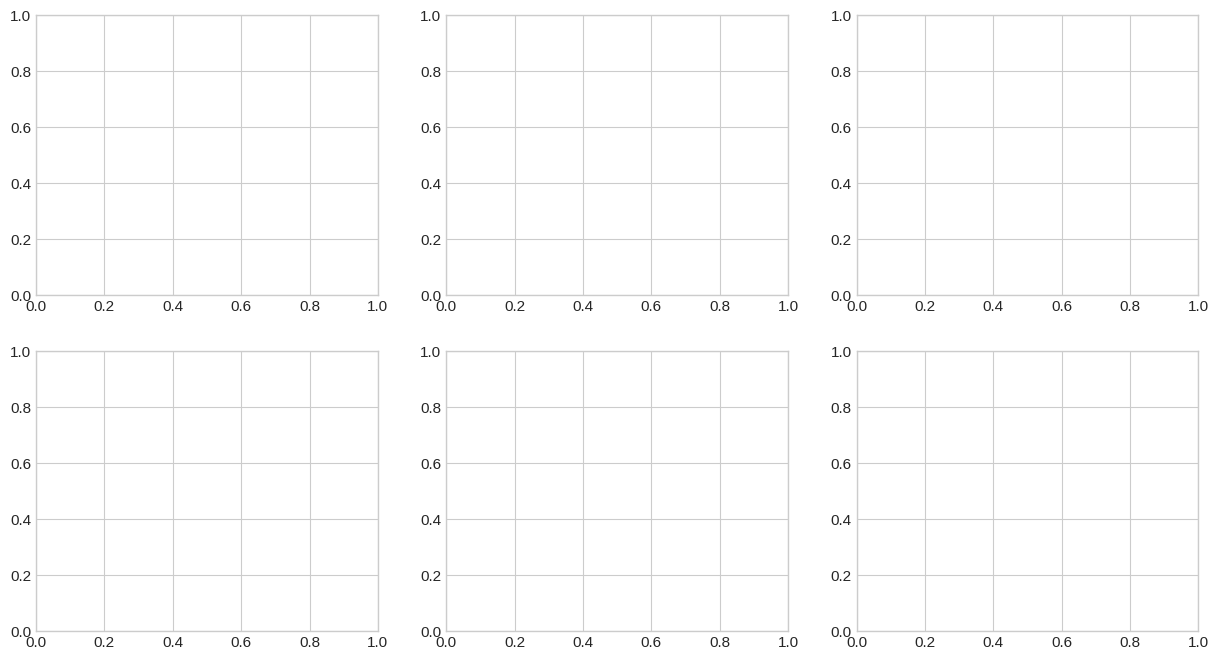

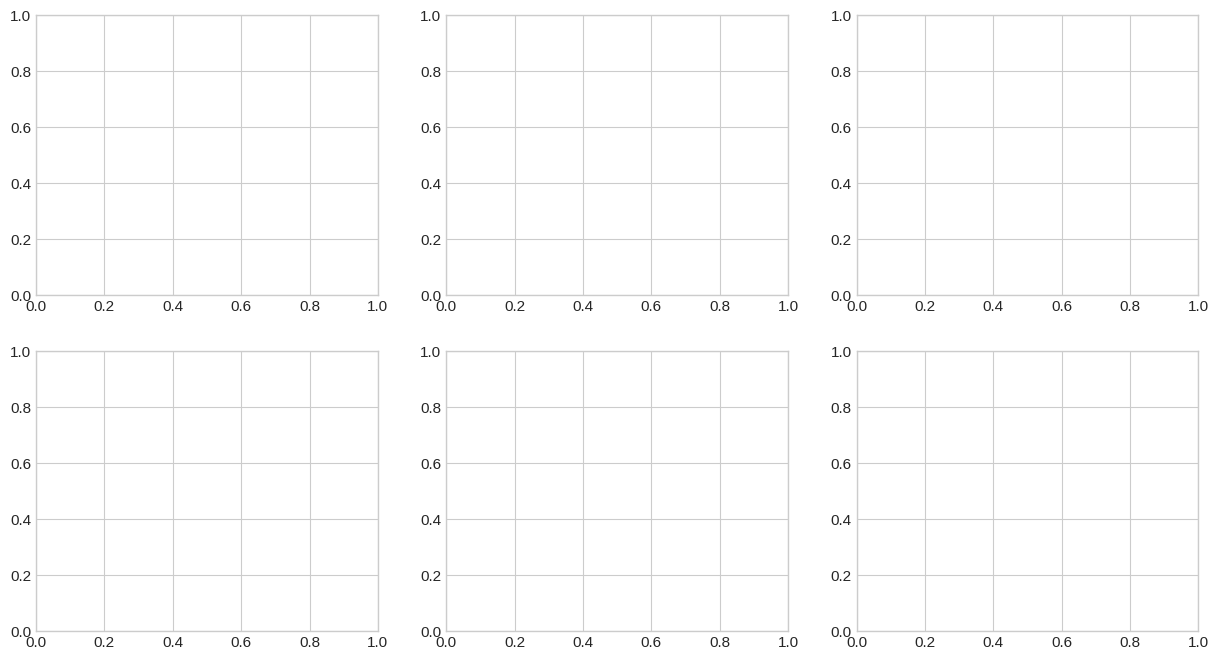

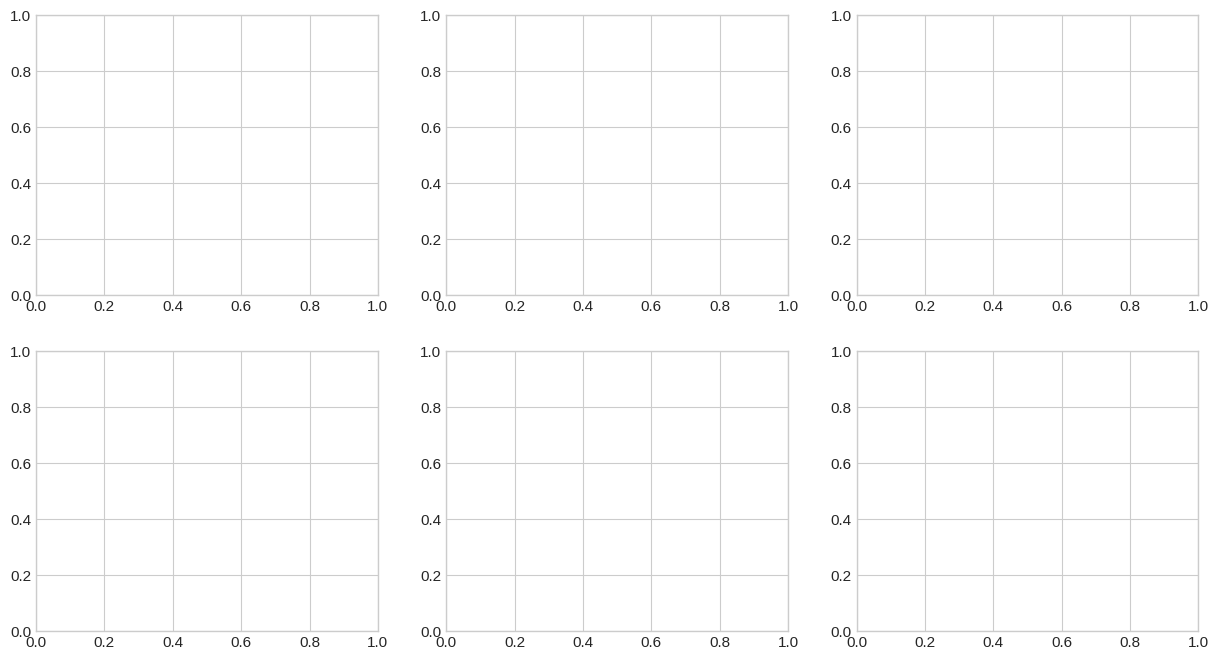

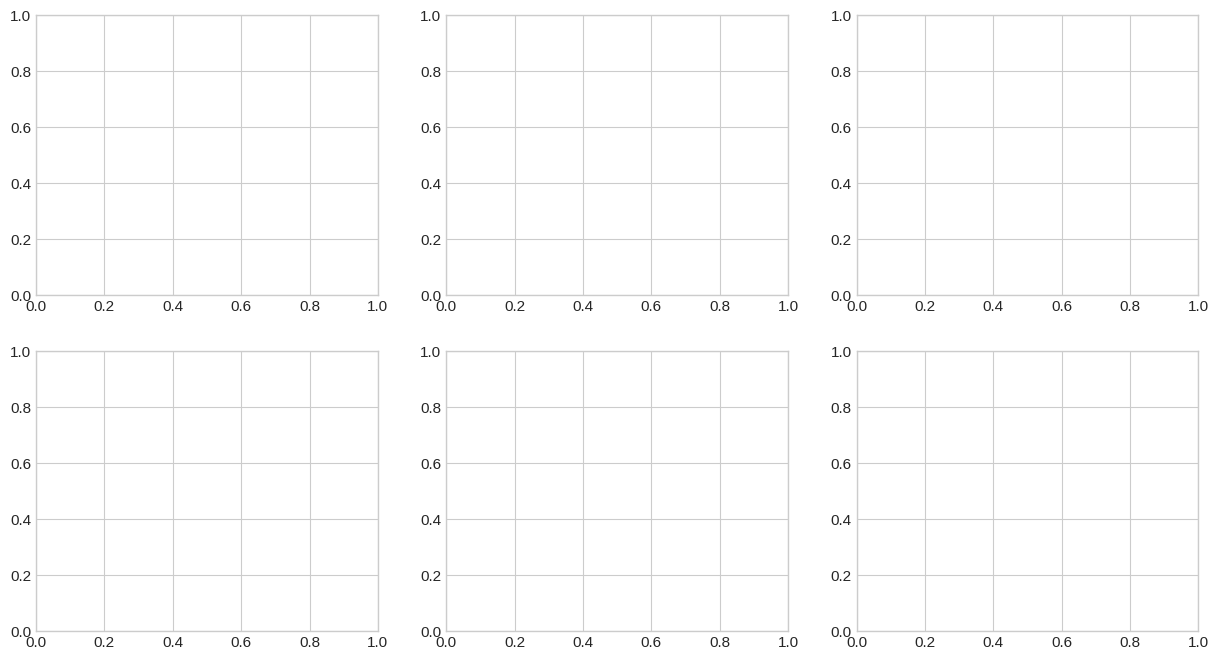

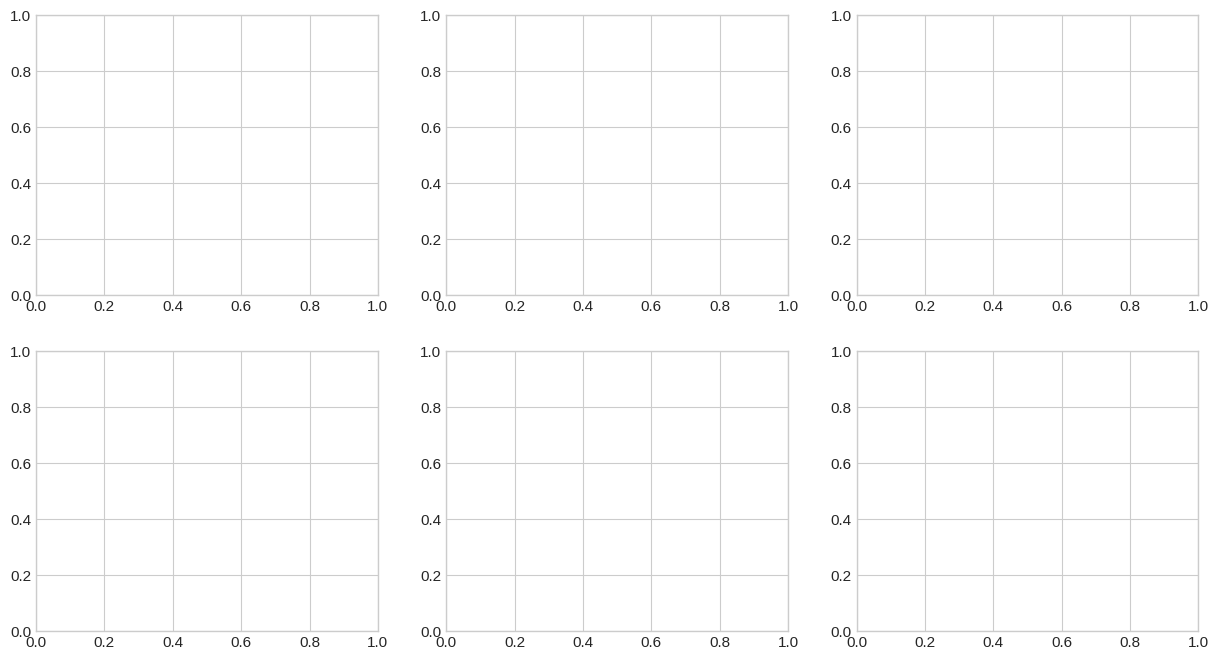

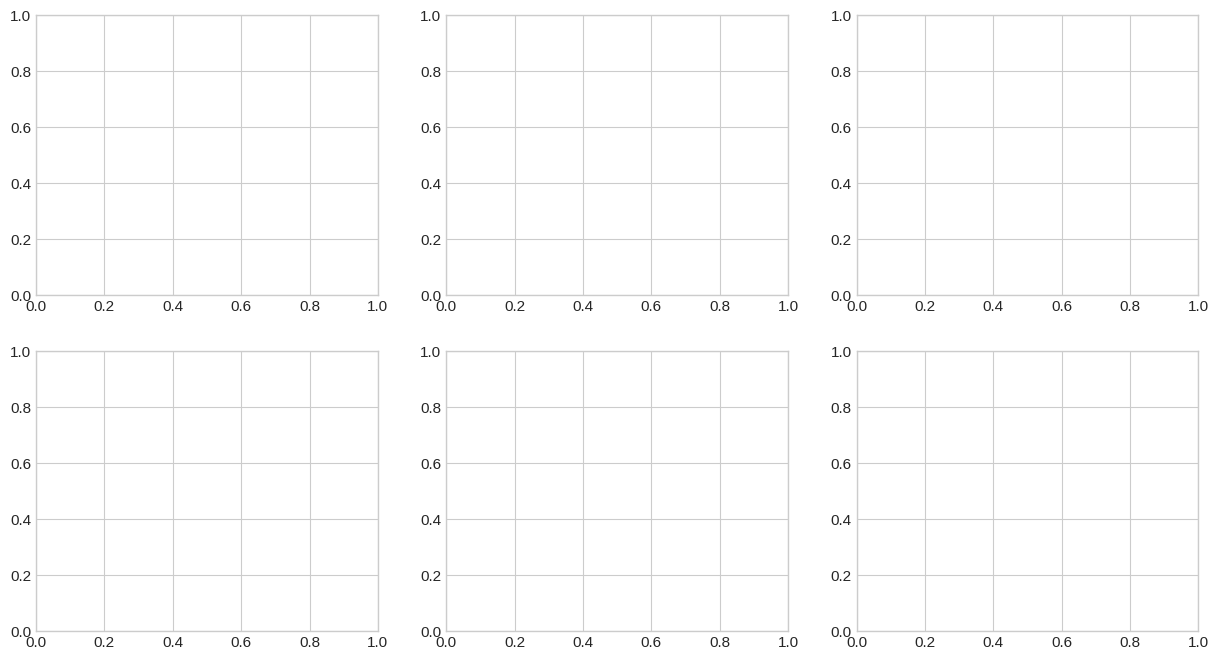

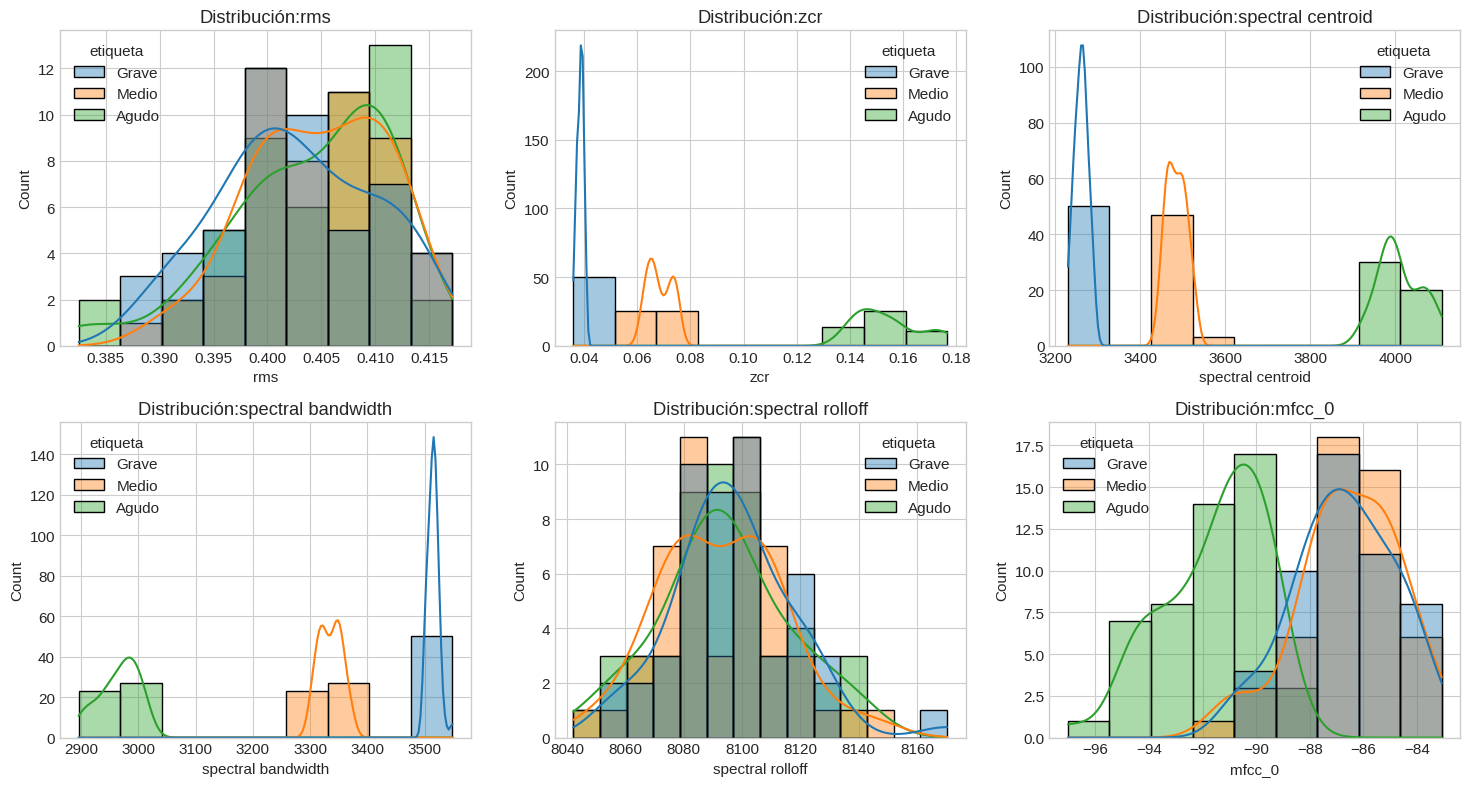

Observa si las  distribuciones se superponen o estás separadas etre clases.


In [5]:
import seaborn as sns # Importar seaborn

print("ESTADÍSTICOS DESCRIPTIVOS POR CLASE\n") # Corregido /n a \n
print("="*80)

features_numericas = ['rms','zcr', 'spectral centroid', 'spectral bandwidth', 'spectral rolloff', 'mfcc_0', 'mfcc_1'] # Corregido 'spectral_bandwisth' a 'spectral bandwidth'

for feature in features_numericas:
  print(f"\n{feature.upper()}:") # Corregido SyntaxError y /n a \n
  print(df.groupby('etiqueta')[feature].agg(['mean', 'std', 'min', 'max']).round (4))
  print("="* 60)

  fig, axes = plt.subplots(2,3, figsize=(15,8))
  axes = axes.flatten()

for idx, feature in enumerate (features_numericas [:6]):
  sns.histplot (data=df, x=feature, hue='etiqueta', kde=True, ax=axes[idx], alpha = 0.4)
  axes [idx].set_title (f'Distribución:{feature}')

plt.tight_layout()
plt.show()

print("Observa si las  distribuciones se superponen o estás separadas etre clases.")

## AplicacióndeFFT-AnálisisFrecuencial

📋 FFT - Ejemplo de cada clase:


CLASE: GRAVE (f1=285 Hz,
           f2=413 Hz)


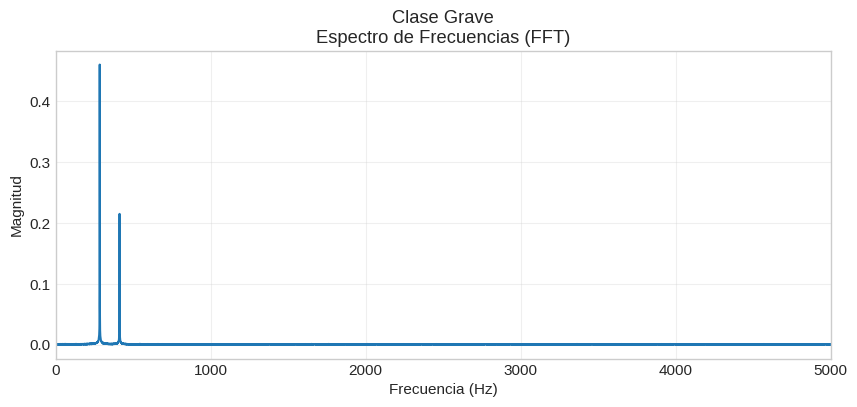

🔍 Picos principales detectados:
 • 285.0 Hz (magnitud: 0.460)
 • 413.0 Hz (magnitud: 0.215)

CLASE: MEDIO (f1=636 Hz,
           f2=1173 Hz)


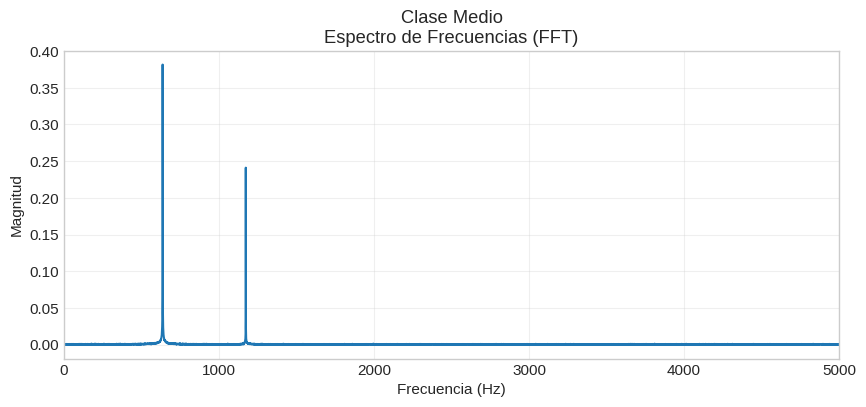

🔍 Picos principales detectados:
 • 636.0 Hz (magnitud: 0.382)
 • 1172.5 Hz (magnitud: 0.241)

CLASE: AGUDO (f1=1559 Hz,
           f2=2872 Hz)


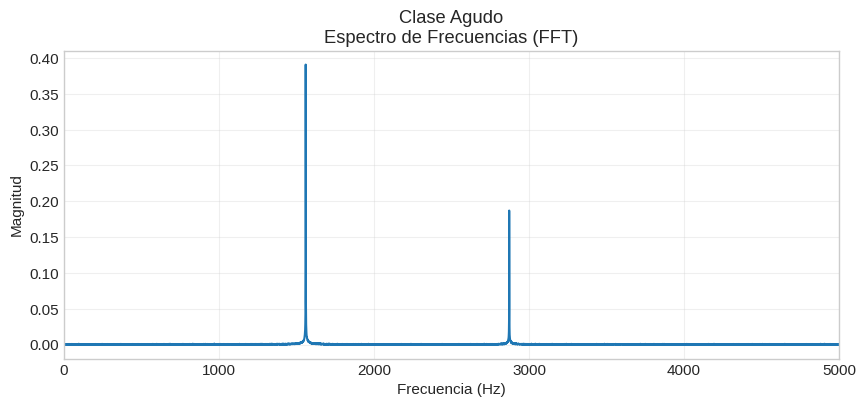

🔍 Picos principales detectados:
 • 1559.0 Hz (magnitud: 0.391)
 • 2872.0 Hz (magnitud: 0.187)


In [8]:
import numpy.fft as fft # Importar fft de numpy
from scipy.signal import find_peaks

def visualizar_fft_ejemplo(audio, sr, titulo="FFT"):
    """Calcula y visualiza la FFT de una señal"""
    # Calcular FFT
    N = len(audio)
    T = 1.0 / sr
    yf = fft.fft(audio)
    xf = fft.fftfreq(N, T)[:N // 2]
    # Magnitud (solo mitad positiva)

    magnitud = 2.0 / N * np.abs(yf[0:N // 2])

    # Gráfico
    plt.figure(figsize=(10, 4))
    plt.plot(xf, magnitud, linewidth=1.5)
    plt.title(f'{titulo}\nEspectro de Frecuencias (FFT)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, 5000) # Limitar a 5 kHz para mejor visualización
    plt.grid(True, alpha=0.3)
    plt.show()

    # Encontrar picos principales
    peaks, properties = find_peaks(magnitud, height=0.1, distance=100)
    print(f"🔍 Picos principales detectados:")
    for peak in peaks[:5]: # Mostrar top 5
        print(f" • {xf[peak]:.1f} Hz (magnitud: {magnitud[peak]:.3f})")

# Seleccionar un ejemplo de cada clase
print("📋 FFT - Ejemplo de cada clase:\n")
for clase in range(3):
    idx = df[df['clase'] == clase].index[0]
    muestra = dataset[idx]
    print(f"\n{'=' * 60}")
    # Corrected multi-line f-string syntax
    print(
        f"CLASE: {muestra['etiqueta'].upper()} (f1={muestra['f1_reales']:.0f} Hz,\n"
        f"           f2={muestra['f2_reales']:.0f} Hz)"
    )
    print('=' * 60)
    visualizar_fft_ejemplo(muestra['audio'], muestra['sr'],
                           f"Clase {muestra['etiqueta'].capitalize()}")

## EspectrogramasSTFT

🎨 ESPECTROGRAMAS COMPARATIVOS



/tmp/ipykernel_21667/1843315634.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


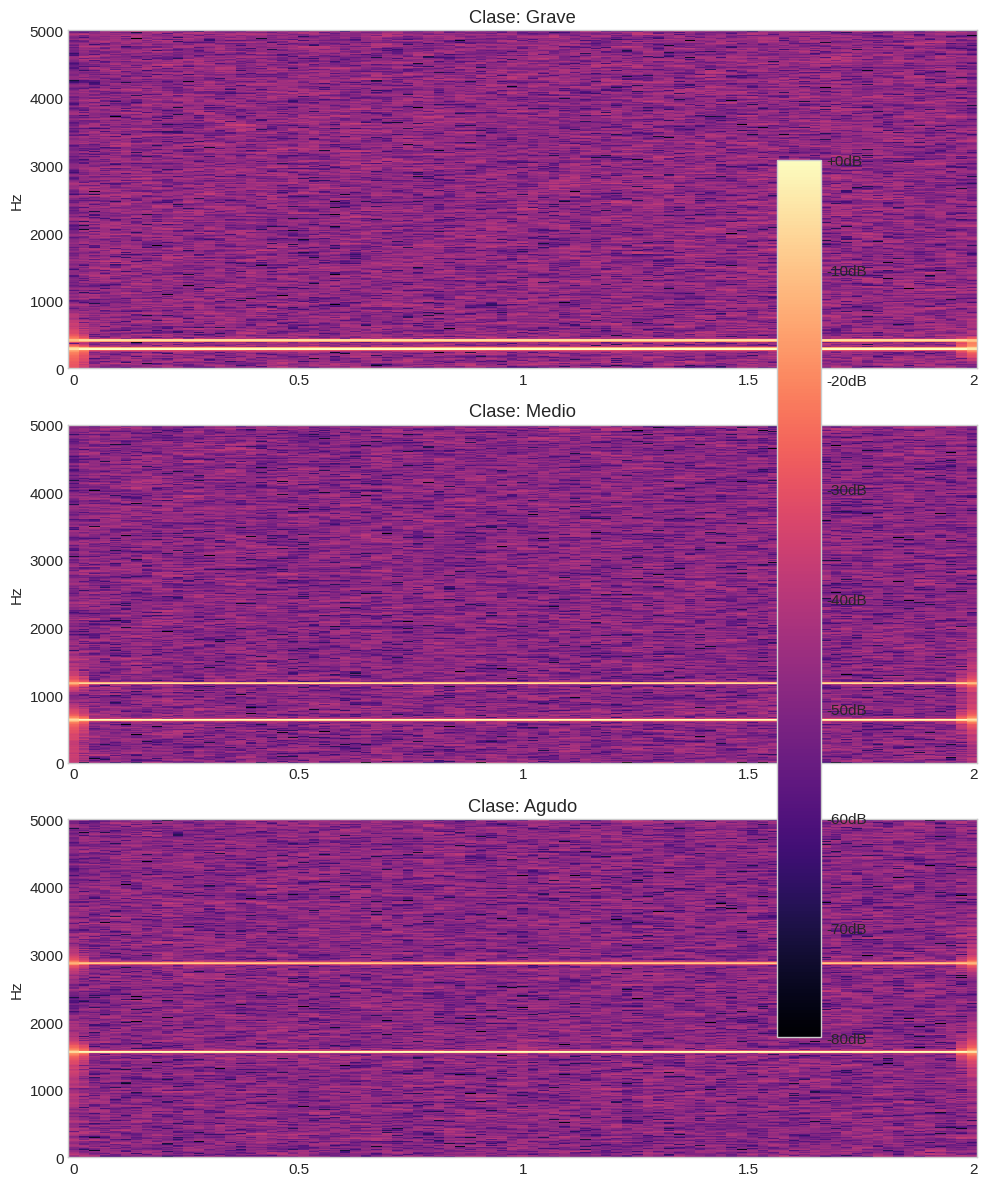

💡 Observa las bandas horizontales brillantes: son las frecuencias dominantes.


In [10]:
def visualizar_espectrograma(audio, sr, titulo="Espectrograma"):
    """Genera espectrograma usando STFT"""
    # Calcular STFT
    D = librosa.stft(audio, n_fft=2048, hop_length=512, window='hann')
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    # Gráfico
    plt.figure(figsize=(10, 5))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz',
                             hop_length=512, cmap='magma')
    plt.title(titulo)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Frecuencia (Hz)')
    plt.colorbar(format='%+2.0fdB')
    plt.ylim(0, 5000) # Limitar a 5 kHz
    plt.tight_layout()
    plt.show()

# Comparar espectrogramas de las 3 clases
print("🎨 ESPECTROGRAMAS COMPARATIVOS\n")
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for idx, clase in enumerate(range(3)):
    idx_df = df[df['clase'] == clase].index[0]
    muestra = dataset[idx_df]
    # Calcular STFT
    D = librosa.stft(muestra['audio'], n_fft=2048, hop_length=512)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    # Mostrar
    img = librosa.display.specshow(S_db, sr=muestra['sr'], x_axis='time',
                                   y_axis='hz', ax=axes[idx], cmap='magma',
                                   hop_length=512)
    axes[idx].set_title(f"Clase: {muestra['etiqueta'].capitalize()}")
    axes[idx].set_xlabel('')
    axes[idx].set_ylim(0, 5000)

plt.colorbar(img, ax=axes, format='%+2.0fdB', shrink=0.95)
plt.tight_layout()
plt.show()
print("💡 Observa las bandas horizontales brillantes: son las frecuencias dominantes.")


## MatrizdeCorrelación

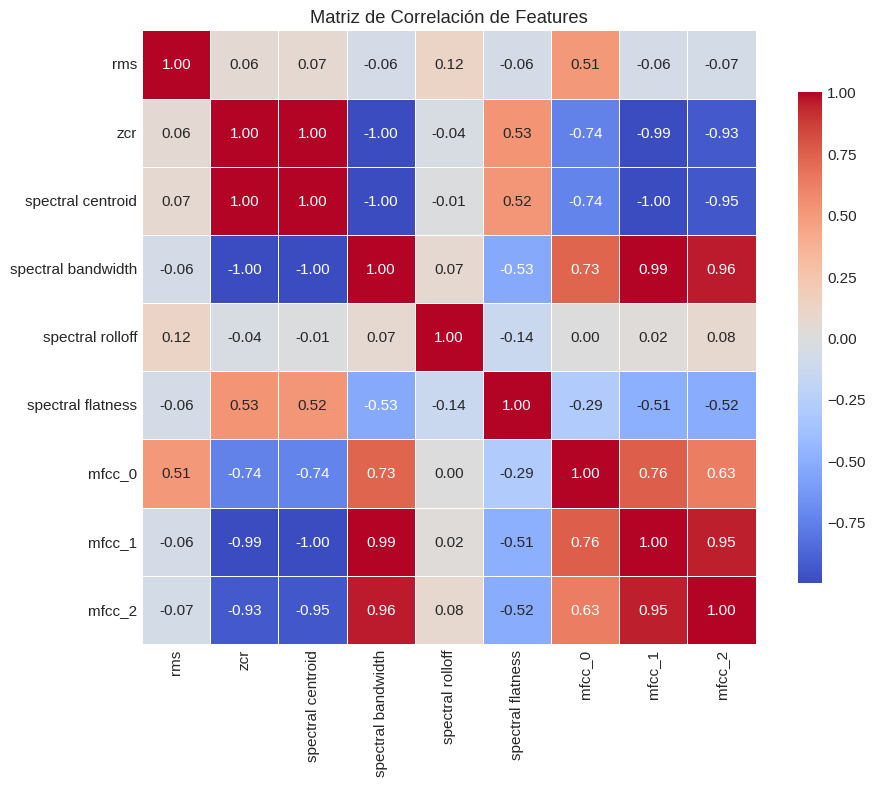


🔍 CORRELACIONES ALTAS (|r|>0.7):
zcr                  ↔ spectral centroid   : r= 0.996
zcr                  ↔ spectral bandwidth  : r= -0.995
zcr                  ↔ mfcc_0              : r= -0.743
zcr                  ↔ mfcc_1              : r= -0.992
zcr                  ↔ mfcc_2              : r= -0.928
spectral centroid    ↔ spectral bandwidth  : r= -0.997
spectral centroid    ↔ mfcc_0              : r= -0.738
spectral centroid    ↔ mfcc_1              : r= -0.997
spectral centroid    ↔ mfcc_2              : r= -0.945
spectral bandwidth   ↔ mfcc_0              : r= 0.728
spectral bandwidth   ↔ mfcc_1              : r= 0.995
spectral bandwidth   ↔ mfcc_2              : r= 0.956
mfcc_0               ↔ mfcc_1              : r= 0.757
mfcc_1               ↔ mfcc_2              : r= 0.946

💡 Features altamente correlacionadas pueden ser redundantes.


In [12]:
# Seleccionar solo columnas numéricas para correlación
cols_correlacion = ['rms', 'zcr', 'spectral centroid', 'spectral bandwidth',
'spectral rolloff', 'spectral flatness', 'mfcc_0', 'mfcc_1', 'mfcc_2']
# Calcular matriz de correlación
corr_matrix = df[cols_correlacion].corr()
# Visualizar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Features')
plt.tight_layout()
plt.show()
# Identificar correlaciones altas
print("\n🔍 CORRELACIONES ALTAS (|r|>0.7):")
print("="*60)
for i in range(len(cols_correlacion)):
    for j in range(i+1, len(cols_correlacion)):
        corr_val = abs(corr_matrix.iloc[i, j])
        if corr_val > 0.7:
            print(f"{cols_correlacion[i]:<20} ↔ {cols_correlacion[j]:<20}: r= {corr_matrix.iloc[i, j]:.3f}")
print("\n💡 Features altamente correlacionadas pueden ser redundantes.")

## VisualizaciónMultidimensionalconPCA

📊 PCA - Varianza explicada:
 PC1:99.56%
 PC2:0.39%
 Total:99.95%


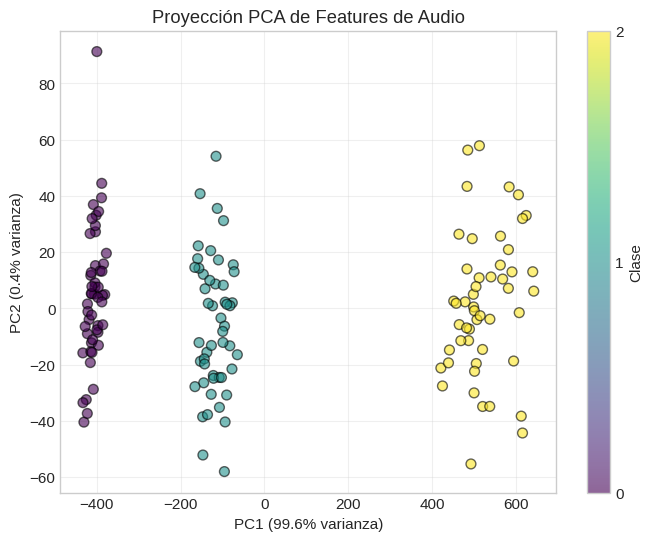


💡 Si las clases están separadas en PCA, las features son discriminativas.


In [14]:
from sklearn.decomposition import PCA

# Preparar datos para PCA
features_pca=['rms', 'zcr', 'spectral centroid', 'spectral bandwidth',
'spectral rolloff', 'mfcc_0', 'mfcc_1', 'mfcc_2']
X=df[features_pca].values
y=df['clase'].values
# Aplicar PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
# Explicar varianza
print("📊 PCA - Varianza explicada:")
print(f" PC1:{pca.explained_variance_ratio_[0]:.2%}")
print(f" PC2:{pca.explained_variance_ratio_[1]:.2%}")
print(f" Total:{sum(pca.explained_variance_ratio_):.2%}")
# Visualizar proyección
plt.figure(figsize=(8,6))
scatter=plt.scatter(X_pca[:,0],X_pca[:,1],c=y,cmap='viridis',
alpha=0.6,s=50,edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.title('Proyección PCA de Features de Audio')
plt.colorbar(scatter, ticks=[0,1,2], label='Clase')
plt.grid(True,alpha=0.3)
plt.show()
print("\n💡 Si las clases están separadas en PCA, las features son discriminativas.")

## DeteccióndeOutliers

🔍 DETECCIÓN DE OUTLIERS (Método IQR)


SPECTRAL CENTROID:
 Rango normal: [2218.0437,5031.1645]
Outliers detectados: 0 (0.0%)

RMS:
 Rango normal: [0.3836,0.4253]
Outliers detectados: 1 (0.7%)
 IDs: [95]...

ZCR:
 Rango normal: [-0.1178,0.3016]
Outliers detectados: 0 (0.0%)


/tmp/ipykernel_21667/2335804192.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='etiqueta', y=feature, ax=axes[idx], palette='pastel')
/tmp/ipykernel_21667/2335804192.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='etiqueta', y=feature, ax=axes[idx], palette='pastel')
/tmp/ipykernel_21667/2335804192.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='etiqueta', y=feature, ax=axes[idx], palette='pastel')


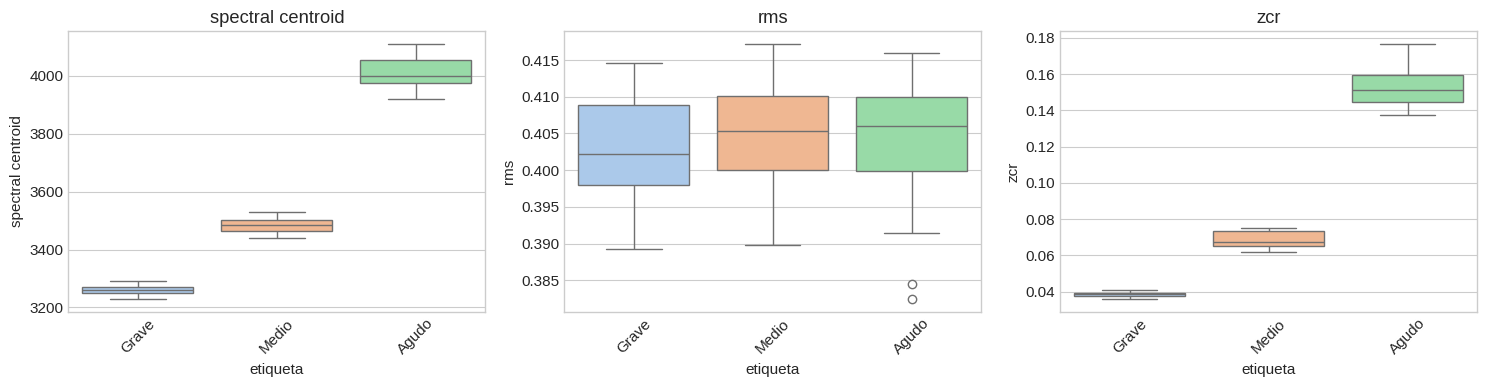


💡 Los outliers pueden ser errores de grabación o eventos raros interesantes.


In [16]:
def detectar_outliers_iqr(df, columna):
    """Detecta outliers usando el método IQR"""
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < limite_inf) | (df[columna] > limite_sup)]
    return outliers, limite_inf, limite_sup

# Detectar outliers en features clave
print("🔍 DETECCIÓN DE OUTLIERS (Método IQR)\n")
print("="*70)

features_a_revisar=['spectral centroid', 'rms', 'zcr'] # Corrected 'spectral_centroid'
for feature in features_a_revisar:
    outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, feature)
    print(f"\n{feature.upper()}:")
    print(f" Rango normal: [{lim_inf:.4f},{lim_sup:.4f}]")
    print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
    if len(outliers) > 0:
        print(f" IDs: {outliers['id'].tolist()[:5]}...") # Mostrar primeros 5

# Visualizar con boxplot
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for idx, feature in enumerate(features_a_revisar):
    sns.boxplot(data=df, x='etiqueta', y=feature, ax=axes[idx], palette='pastel')
    axes[idx].set_title(f'{feature}')
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("\n💡 Los outliers pueden ser errores de grabación o eventos raros interesantes.")

## ResumenEstadísticodelDataset

In [18]:
#Crearreporteautomático
print("="*80)
print("📊REPORTECOMPLETODEEDA-DATASETDEAUDIO")
print("="*80)
print(f"\n📁INFORMACIÓNGENERAL:")
print(f" •Totaldemuestras:{len(df)}")
print(f" •Númerodeclases:{df['clase'].nunique()}")
print(f" •Featuresextraídas:{len(features_pca)}")
print(f"\n📊DISTRIBUCIÓNPORCLASE:")
print(df['etiqueta'].value_counts().to_string())
print(f"\n📏DURACIÓN:")
print(f" •Media:{df['duracion'].mean():.2f}s")
print(f" •Desviación:{df['duracion'].std():.2f}s")
print(f" •Rango: [{df['duracion'].min():.2f},{df['duracion'].max():.2f}]s")
print(f"\n🎵FEATURESPRINCIPALES(media±stdporclase):")
for feature in ['spectral centroid', 'rms', 'zcr']:
  print(f"\n {feature.upper()}:")
  for clase in df['etiqueta'].unique():
    media = df[df['etiqueta']==clase][feature].mean()
    std = df[df['etiqueta']==clase][feature].std()
    print(f"  {clase:8s}:{media:.4f}±{std:.4f}")
print("\n"+"="*80)
print("✅EDAcompletado.Dataset listoparamodelado.")
print("="*80)

📊REPORTECOMPLETODEEDA-DATASETDEAUDIO

📁INFORMACIÓNGENERAL:
 •Totaldemuestras:150
 •Númerodeclases:3
 •Featuresextraídas:8

📊DISTRIBUCIÓNPORCLASE:
etiqueta
Grave    50
Medio    50
Agudo    50

📏DURACIÓN:
 •Media:2.00s
 •Desviación:0.00s
 •Rango: [2.00,2.00]s

🎵FEATURESPRINCIPALES(media±stdporclase):

 SPECTRAL CENTROID:
  Grave   :3260.9111±15.9823
  Medio   :3485.1616±23.4837
  Agudo   :4011.3450±50.5197

 RMS:
  Grave   :0.4027±0.0072
  Medio   :0.4049±0.0063
  Agudo   :0.4041±0.0075

 ZCR:
  Grave   :0.0386±0.0013
  Medio   :0.0685±0.0044
  Agudo   :0.1539±0.0116

✅EDAcompletado.Dataset listoparamodelado.


# RESPUESTAS

## CONSIGNA 1)

**a)**  La frecuencia fundamental es 250 Hz. Es la frecuencia más baja y dominante en el espectro, y es la que nuestro oído percibe como el tono principal o la "altura" de la nota. Por eso, al escuchar la clase "grave" con estos picos, la percibiríamos en 250 Hz.

**b)** El segundo pico, a 450 Hz, representa un armónico o un sobretono. En este caso, no es un múltiplo exacto de 250 Hz (no es un armónico perfecto), pero es otra frecuencia importante que contribuye a la riqueza del sonido. Estos picos adicionales, junto con la frecuencia fundamental, son los que determinan el "color" o la "calidad" del sonido.

**c)** Si agregamos un pico a 750 Hz, el timbre del sonido cambiaría significativamente. Como 750 Hz es el tercer armónico (3 veces 250 Hz), la adición de esta nueva frecuencia a la mezcla haría que el sonido se percibiera más complejo. El timbre se define precisamente por la combinación de la frecuencia fundamental y sus armónicos/sobretonos. Introducir una nueva componente armónica enriquece el espectro y altera la cualidad distintiva del sonido, haciéndolo diferente del original con solo dos picos.

## CONSIGNA 2)

**a)** Están correlacionadas ya que si un sonido tiene mucha energía en las frecuencias altas (alto spectral centroid), su 'punto de corte' donde se concentra la mayor parte de la energía también estará en una frecuencia alta (alto spectral rolloff). Por eso, tienden a subir y bajar juntas.

**b)** Una correlación de r=0.89 es muy alta, lo que sugiere que ambas características están capturando información muy similar.

Mantener ambas podría llevar a:
**Redundancia**: No aportan información significativamente nueva al modelo.
**Multicolinealidad:** En algunos modelos de Machine Learning (como la regresión lineal), esto puede causar inestabilidad y dificultad para interpretar los coeficientes.
**Mayor complejidad:** Más características implican más cálculos y un modelo potencialmente más lento y difícil de entrenar.

Se podría elegir entre la que tenga una correlación más fuerte con la variable objetivo, o simplemente la que sea más fácil de interpretar.

**c)** Podríamos mantener ambas en las siguinetes situaciones:

**Si aportan matices distintos**: podrían capturar sutiles diferencias que son cruciales para un análisis muy detallado o para la tarea específica de clasificación.

**Si el modelo lo requiere**: Si al probar el modelo, este funciona mejor con ambas características y la multicolinealidad no es un problema evidente.

## CONSIGNA 3)

## NOTA: hay una diferencia entre los resultados de PCA obtenidos en el desarrollo del Colab y los que figuran en la consigna 3.
Voy a responder en relación  a los resultados que obtuvimos en el Colab, ya que la suma de ambos PCA 1 y 2, da como resultado 99.95% que abarca casi el total de la sumatoria de las varianzas.

**a)** PC1 abarca la mayor parte de las diferencias entre las muestras. Mientras que PC2 captura una cantidad muy pequeña de la varianza (0.39%) restante.

**b)** En este caso sí, dado que entre PC1 y PC2 explican el 99.95% de la varianza total, prácticamente toda la información discriminatoria y la estructura de los datos están contenidas en estas dos dimensiones.

**c)** El mayor valor absoluto en el vector de pca.components_ correspondiente a PC1, sería la que más contribuye a esa componente principal. Esto significa que esa característica tiene una gran influencia en la dirección y el significado de PC1. Sin imprimir explícitamente pca.components_ no podemos saberlo directamente de las salidas actuales, pero este es el método para averiguarlo.

#CONSIGNA 4)

**a)** En caso de haber detectado un 5% de Outliers en ZCR haría lo siguinete:

No los eliminaría automáticamente:  podríamos estar sesgando nuestro dataset y perdiendo información crucial.

**b)** Revisar la fuente de datos: ¿Hay alguna razón conocida por la que esos datos podrían ser atípicos?

Visualización detallada: Analizar los outliers en el contexto de otras características relevantes. Ayudaría a entender si son valores aislados o si forman un grupo con alguna característica común.

Análisis por clase: Comprobar si los outliers se concentran en alguna clase específica. (puede que se trate de un comportamiento normal para una clase particular.)

Impacto en el modelo: se debeconsiderar qué impacto tendrían estos outliers en los modelos de Machine Learning que se vayan a utilizar.

**c)** Estrategia de manejo de outliers:


*   Investigación y corrección (si es un error): determina que el outlier es claramente un error de medición o de entrada de datos, intentaría corregirlo si es posible. Si no es posible, entonces sí se podría considerar eliminarlo.

*   Transformación de datos: (Reducir el efecto de los valores extremos sin eliminarlos.)

* Imputación: En lugar de eliminar las muestras completas, podría intentar reemplazar el valor outlier de zcr con un valor imputado.

*   Creación de una característica binaria: Podrímos crear una nueva característica binaria que indique si una muestra es un outlier o no. Esto permite que el modelo aprenda a tratar estas muestras de manera diferente.

*  Eliminación (último recurso): Solo consideraría la eliminación de las muestras con outliers si estos son poco  no son errores corregibles, y se demuestra que su presencia afecta negativamente y de forma significativa el rendimiento del modelo






